# 3 — The field of the stigmatic ovoid

The optical surface is a cap; a boundary-integral formulation needs a closed
body.  `ovoid_body` closes it with a cylinder at the rim radius and a cone,
both outside the converging beam, so no ray reaches them before A′.  A
closed lossless dielectric is nevertheless a resonator, so the direct beam
coexists with trapped modes.

Set `RECOMPUTE = True` to rerun the solves (about 10 minutes); otherwise the
stored results in `benchmarks/golden` are used.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
from nbstyle import *

RECOMPUTE = False

if RECOMPUTE:
    sys.path.insert(0, str(ROOT / "benchmarks"))
    from compute_fields import ovoid_fields, ovoid_po
    ovoid_fields()
    ovoid_po()

OV = load("ovoid_fields")       # BEM, n2 real
PO = load("ovoid_po")           # tangent-plane model on the cap alone

zi, zo = float(OV["zi"]), float(OV["zo"])
airy, NA = float(OV["airy"]), float(OV["NA"])
print(f"source A at z\u2080 = {zo:.0f}\u03bb, design focus A\u2032 at z = {zi:.0f}\u03bb")
print(f"NA = {NA:.3f}, \u03b8\u2082,max = {np.degrees(float(OV['th2max'])):.1f}\u00b0, "
      f"Airy radius 0.61\u03bb/NA = {airy:.3f}\u03bb")
print(f"rim r = {float(OV['r_rim']):.2f}\u03bb at z = {float(OV['z_rim']):.2f}\u03bb; "
      f"body closes at z = {float(OV['z_end']):.1f}\u03bb, apex {float(OV['z_apex']):.1f}\u03bb")
print(f"BEM mesh: N = {int(OV['N'])} panels at {float(OV['ppl']):.0f} panels/\u03bb\u2082")

source A at z₀ = -16λ, design focus A′ at z = 8λ
NA = 0.750, θ₂,max = 30.0°, Airy radius 0.61λ/NA = 0.813λ
rim r = 2.97λ at z = 2.85λ; body closes at z = 20.8λ, apex 22.4λ
BEM mesh: N = 1236 panels at 32 panels/λ₂


## Meridional sections

Two solutions of the same geometry.  Each panel is normalised to its own
peak within 1.5λ of A′ on the axis, so the shapes are comparable.

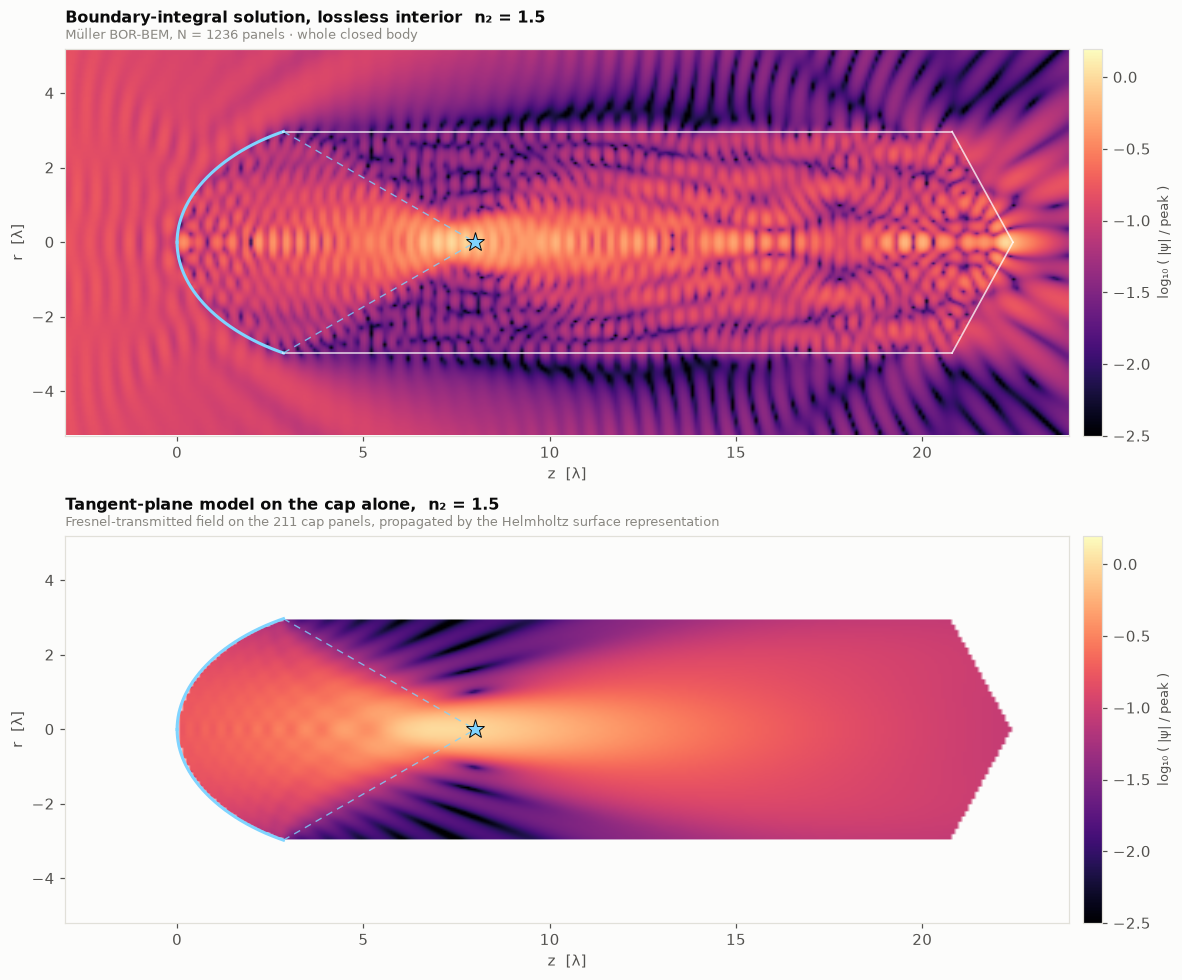

In [2]:
def geometry_overlay(ax, D, shroud=True):
    r_rim, z_end = float(D["r_rim"]), float(D["z_end"])
    z_apex, zi_ = float(D["z_apex"]), float(D["zi"])
    for s in (1, -1):
        ax.plot(D["cap_z"], s * D["cap_r"], color=EDGE, lw=2.0)
        if shroud:
            ax.plot([D["cap_z"][-1], z_end], [s * r_rim] * 2, color="white",
                    lw=1.1, alpha=.75)
            ax.plot([z_end, z_apex], [s * r_rim, 0], color="white", lw=1.1,
                    alpha=.75)
        ax.plot([D["cap_z"][-1], zi_], [s * r_rim, 0], color=EDGE, lw=0.9,
                ls=(0, (5, 4)), alpha=.8)
    ax.plot(zi_, 0, "*", ms=13, color=EDGE, mec="black", mew=.6)
    ax.set_ylim(-5.2, 5.2)

fig, ax = plt.subplots(2, 1, figsize=(13.5, 9.0))
psi_po = PO["psi"].copy(); psi_po[~OV["inside"]] = np.nan
rows = [(ax[0], OV["psi"], OV, True,
         "Boundary-integral solution, lossless interior  n\u2082 = 1.5",
         f"M\u00fcller BOR-BEM, N = {int(OV['N'])} panels \u00b7 whole closed body"),
        (ax[1], psi_po, OV, False,
         "Tangent-plane model on the cap alone,  n\u2082 = 1.5",
         f"Fresnel-transmitted field on the {int(PO['n_cap'])} cap panels, "
         f"propagated by the Helmholtz surface representation")]
for a, psi, D, shroud, head, sub in rows:
    im = meridional(a, D["rg"], D["zg"], psi, focal_peak(OV, psi))
    geometry_overlay(a, D, shroud)
    plt.colorbar(im, ax=a, fraction=0.019, pad=0.01).set_label(
        "log\u2081\u2080 ( |\u03c8| / peak )", fontsize=8.5)
    ttl(a, head, sub)
plt.tight_layout(); plt.show()

With $n_2$ real the converging cone and A′ are there, but so is a field
of comparable strength filling the whole body — the closed lossless
dielectric is a resonator.  The model on the cap alone produces the
same beam and nothing else, because it has no mechanism for multiple
scattering.

## The focal region

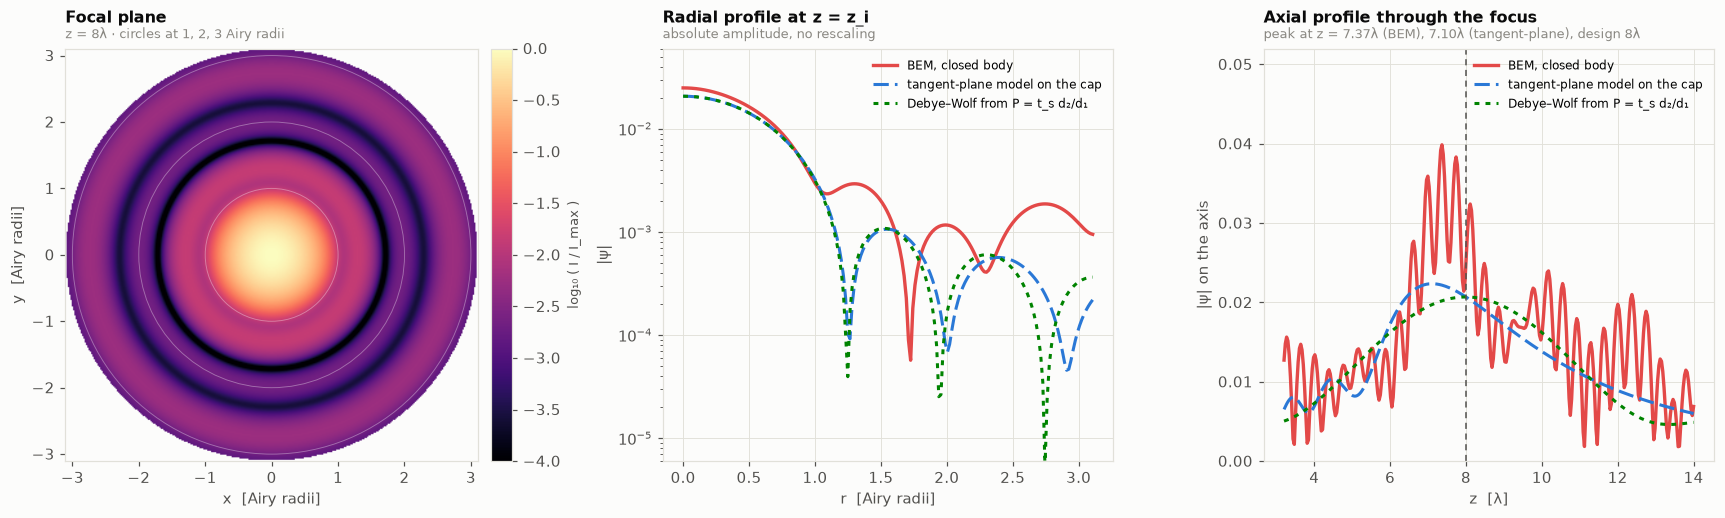

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15.8, 4.8))

I = np.abs(OV["psi_tr"]) ** 2
xs = np.linspace(-OV["r_tr"][-1], OV["r_tr"][-1], 320)
X, Y = np.meshgrid(xs, xs)
img = np.interp(np.hypot(X, Y).ravel(), OV["r_tr"], I / I.max(),
                right=np.nan).reshape(X.shape)
im = ax[0].imshow(np.log10(np.maximum(img, 1e-4)),
                  extent=[-OV["r_tr"][-1] / airy, OV["r_tr"][-1] / airy] * 2,
                  origin="lower", cmap="magma", vmin=-4, vmax=0,
                  interpolation="bilinear")
for m in (1, 2, 3):
    ax[0].add_patch(plt.Circle((0, 0), m, fill=False, color="white", lw=0.6,
                               alpha=0.35))
ax[0].set_xlabel("x  [Airy radii]"); ax[0].set_ylabel("y  [Airy radii]")
ax[0].grid(False)
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.03).set_label(
    "log\u2081\u2080 ( I / I_max )", fontsize=8.5)
ttl(ax[0], "Focal plane",
    f"z = {zi:.0f}\u03bb \u00b7 circles at 1, 2, 3 Airy radii")

CURVES = [("BEM, closed body", RED, "-", 2.2, OV, "psi"),
          ("tangent-plane model on the cap", BLUE, (0, (5, 2)), 2.0, PO, "psi"),
          ("Debye\u2013Wolf from P = t_s d\u2082/d\u2081", GREEN, (0, (1.6, 2)), 2.0, OV, "dw")]

for lab, col, ls, lw, D, key in CURVES:
    ax[1].semilogy(OV["r_tr"] / airy, np.abs(D[key + "_tr"]), color=col, lw=lw,
                   ls=ls, label=lab)
ax[1].set_ylim(6e-6, 6e-2); ax[1].set_xlabel("r  [Airy radii]")
ax[1].set_ylabel("|\u03c8|"); ax[1].legend(fontsize=8.0, loc="upper right")
ttl(ax[1], "Radial profile at z = z_i", "absolute amplitude, no rescaling")

for lab, col, ls, lw, D, key in CURVES:
    ax[2].plot(OV["z_ax"], np.abs(D[key + "_ax"]), color=col, lw=lw, ls=ls,
               label=lab)
ax[2].axvline(zi, color=INK2, lw=1.0, ls=(0, (4, 3)))
ax[2].set_xlabel("z  [\u03bb]"); ax[2].set_ylabel("|\u03c8| on the axis")
ax[2].set_ylim(0, 0.052); ax[2].legend(fontsize=8.0, loc="upper right")
zb, ab_ = OV["z_ax"], np.abs(OV["psi_ax"])
ttl(ax[2], "Axial profile through the focus",
    f"peak at z = {zb[ab_.argmax()]:.2f}\u03bb (BEM), "
    f"{zb[np.abs(PO['psi_ax']).argmax()]:.2f}\u03bb (tangent-plane), design {zi:.0f}\u03bb")
plt.tight_layout(); plt.show()

In [4]:
N_F = float(OV["r_rim"]) ** 2 * 1.5 / zi
print(f"aperture Fresnel number  a² n₂ / (λ z_i) = {N_F:.2f}")
print("the Debye approximation assumes this is large; at this value the "
      "focus of a converging wave sits short of the geometric image point.")

aperture Fresnel number  a² n₂ / (λ z_i) = 1.66
the Debye approximation assumes this is large; at this value the focus of a converging wave sits short of the geometric image point.


## The two reference spheres

$S_1$ is centred on the source A, $S_2$ on the design focus A′.  On each,
the field is demodulated by removing the spherical carrier, which leaves the
amplitude and the phase of the wave as a function of the ray angle:

$$A(\theta) = \psi\,R\,e^{\pm i k R}.$$

For $S_2$ the reference phase is the stigmatic constant $k_0C$, so a flat
curve means the exit wavefront is spherical about A′.

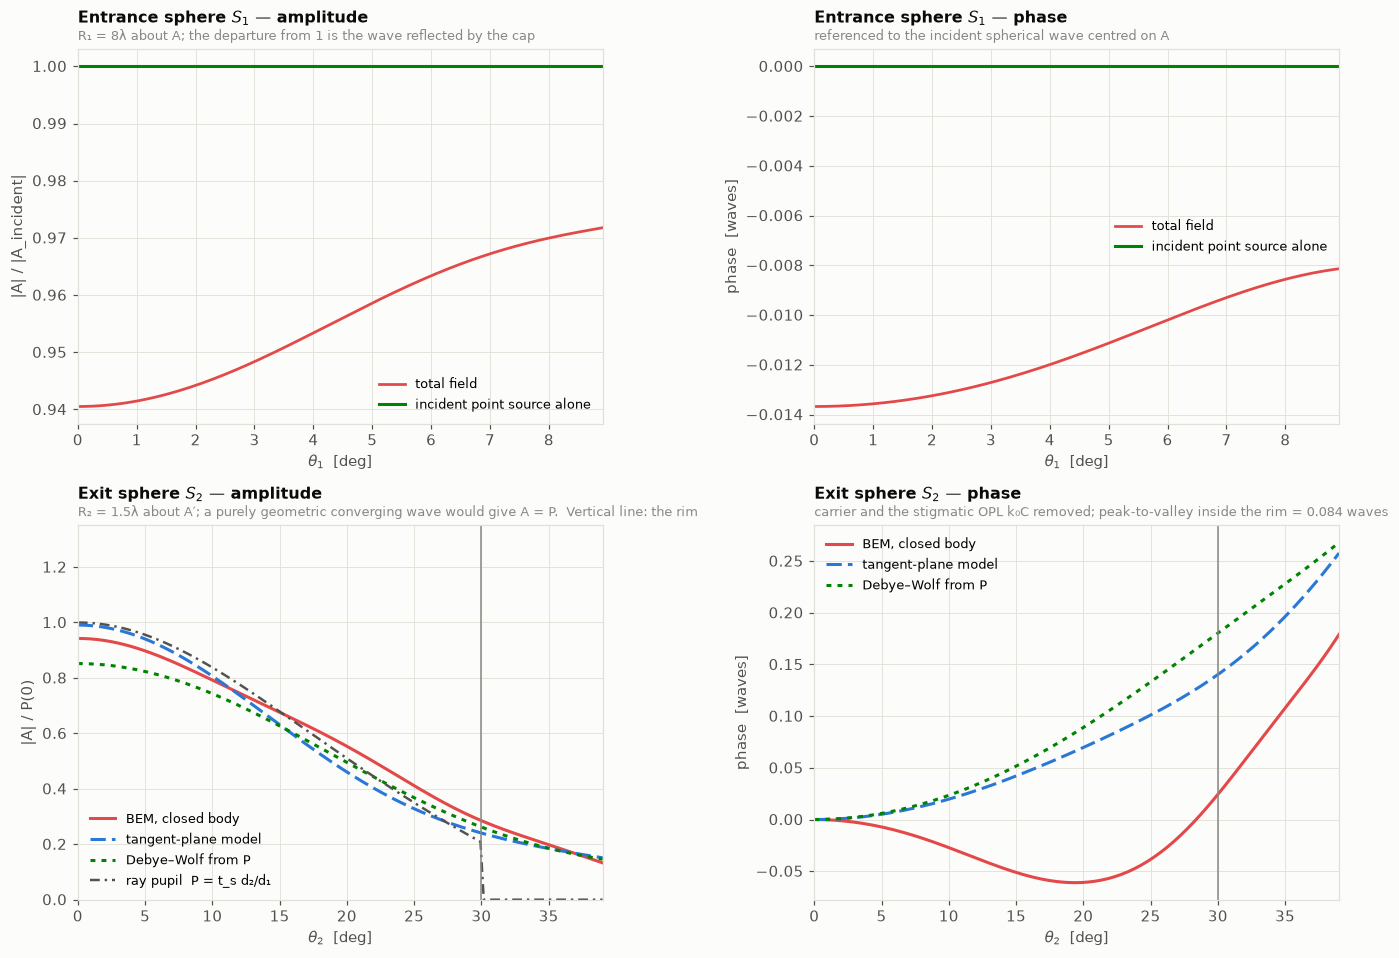

In [5]:
k0, opl = float(OV["k0"]), float(OV["opl"])
thm = np.degrees(float(OV["th2max"]))

def rel_phase(A):
    p = np.unwrap(np.angle(np.asarray(A) * np.exp(-1j * k0 * opl)))
    return (p - p[0]) / (2 * np.pi)

fig, ax = plt.subplots(2, 2, figsize=(13.0, 8.8))

t1 = np.degrees(OV["th1"])
ax[0, 0].plot(t1, np.abs(OV["A1"]) / np.abs(OV["A1_inc"]), color=RED, lw=1.8,
              label="total field")
ax[0, 1].plot(t1, np.angle(OV["A1"] / OV["A1_inc"]) / (2 * np.pi), color=RED,
              lw=1.8, label="total field")
for a, yl in ((ax[0, 0], "|A| / |A_incident|"), (ax[0, 1], "phase  [waves]")):
    a.axhline(1.0 if a is ax[0, 0] else 0.0, color=GREEN, lw=2.0,
              label="incident point source alone")
    a.set_xlabel(r"$\theta_1$  [deg]"); a.set_ylabel(yl)
    a.set_xlim(0, np.degrees(float(OV["th1"][-1])))
ax[0, 0].legend(fontsize=8.5, loc="lower right")
ax[0, 1].legend(fontsize=8.5, loc="center right")
ttl(ax[0, 0], "Entrance sphere $S_1$ \u2014 amplitude",
    f"R\u2081 = {float(OV['R1']):.0f}\u03bb about A; the departure from 1 is the wave "
    f"reflected by the cap")
ttl(ax[0, 1], "Entrance sphere $S_1$ \u2014 phase",
    "referenced to the incident spherical wave centred on A")

P0 = float(np.abs(OV["A2_ray"][0]))
t2 = np.degrees(OV["th2"])
S2 = [(OV["A2"], OV["th2"], RED, "-", "BEM, closed body"),
      (PO["A2"], PO["th2"], BLUE, (0, (5, 2)), "tangent-plane model"),
      (OV["A2_dw"], OV["th2"], GREEN, (0, (1.6, 2)), "Debye\u2013Wolf from P")]
for A, th, col, ls, lab in S2:
    ax[1, 0].plot(np.degrees(th), np.abs(A) / P0, color=col, lw=2.0, ls=ls,
                  label=lab)
    ax[1, 1].plot(np.degrees(th), rel_phase(A), color=col, lw=2.0, ls=ls,
                  label=lab)
ax[1, 0].plot(t2, OV["A2_ray"] / P0, color=INK2, lw=1.6, ls=(0, (4, 2, 1, 2)),
              label="ray pupil  P = t_s d\u2082/d\u2081")
for a in (ax[1, 0], ax[1, 1]):
    a.axvline(thm, color=MUTED, lw=1.0)
    a.set_xlabel(r"$\theta_2$  [deg]"); a.set_xlim(0, t2[-1])
ax[1, 0].set_ylim(0, 1.35); ax[1, 0].set_ylabel("|A| / P(0)")
ax[1, 1].set_ylabel("phase  [waves]")
ax[1, 0].legend(fontsize=8.5, loc="lower left")
ax[1, 1].legend(fontsize=8.5, loc="upper left")
inn = OV["th2"] <= float(OV["th2max"])
ttl(ax[1, 0], "Exit sphere $S_2$ \u2014 amplitude",
    f"R\u2082 = {float(OV['R2']):.1f}\u03bb about A\u2032; a purely geometric converging wave "
    f"would give A = P.  Vertical line: the rim")
ttl(ax[1, 1], "Exit sphere $S_2$ \u2014 phase",
    f"carrier and the stigmatic OPL k\u2080C removed; peak-to-valley inside the rim "
    f"= {np.ptp(rel_phase(OV['A2'])[inn]):.3f} waves")
plt.tight_layout(); plt.show()

In [6]:
inn = OV["th2"] <= float(OV["th2max"])
for nm, A, D in (("BEM, n\u2082 real", OV["A2"], OV),
                 ("tangent-plane", PO["A2"], OV), ("Debye\u2013Wolf", OV["A2_dw"], OV)):
    r = np.abs(A)[inn] / float(np.abs(D["A2_ray"][0]))
    print(f"{nm:16s} A(0)/P(0) = {r[0]:.3f}   A(rim)/P(0) = {r[-1]:.3f}   "
          f"phase PV = {np.ptp(rel_phase(A)[inn]):.4f} waves")
print(f"{'ray pupil':16s} A(0)/P(0) = 1.000   "
      f"A(rim)/P(0) = {float(OV['A2_ray'][inn][-1] / OV['A2_ray'][0]):.3f}   "
      f"phase PV = 0 (by construction)")
s1 = np.abs(OV["A1"] / OV["A1_inc"])
print(f"\nS1 total/incident amplitude: {s1.min():.4f} \u2026 {s1.max():.4f}")

BEM, n₂ real     A(0)/P(0) = 0.943   A(rim)/P(0) = 0.286   phase PV = 0.0842 waves
tangent-plane    A(0)/P(0) = 0.991   A(rim)/P(0) = 0.241   phase PV = 0.1396 waves
Debye–Wolf       A(0)/P(0) = 0.852   A(rim)/P(0) = 0.263   phase PV = 0.1796 waves
ray pupil        A(0)/P(0) = 1.000   A(rim)/P(0) = 0.209   phase PV = 0 (by construction)

S1 total/incident amplitude: 0.9405 … 0.9718


The exit wavefront is spherical about A′ to well under a tenth of a
wave, which is what stigmatism buys.  The amplitude is not constant: it
falls to roughly a quarter of its axial value at the rim, close to the ray
pupil.  The entrance sphere shows the reflected wave as a few per cent
modulation of the incident one.